# 📝 **ML Foundation Week 5: Text Generation using RNN, LSTM & GRU** 📝

### 📚 Machine Learning Foundation – Week 5 Assignment

## 📌 **Project Objective** 📌

The objective of this project is to build and compare three recurrent neural network architectures—Simple RNN, LSTM, and GRU—for next-word prediction and text generation. The project demonstrates how sequential deep learning models learn language patterns from text data and generate meaningful text based on learned context.

## 📊 **Executive Summary** 📊

This project demonstrates text generation using Recurrent Neural Networks (RNNs). A text corpus is preprocessed, tokenized, and transformed into numerical sequences for sequence prediction.

Three different recurrent neural network architectures are implemented:

- Simple RNN
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)

The models are trained to predict the next word in a sentence. Their learning performance is compared using training loss curves, and generated text samples are analyzed to evaluate model effectiveness.

The project highlights the advantages of advanced recurrent architectures in handling sequential language data.

## 📚 **Import Required Libraries** 📚

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense
)

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import EarlyStopping

## 📂 **Load Text Corpus** 📂

The text corpus serves as the training dataset for the language models. It is first converted into numerical form through tokenization before being transformed into input-output sequences for next-word prediction.

In [ ]:
corpus = """
Artificial Intelligence is transforming industries by enabling machines to learn from data and make intelligent decisions.
Machine Learning is one of the most important branches of Artificial Intelligence.
Deep Learning uses artificial neural networks with multiple hidden layers to solve complex problems.
Natural Language Processing enables computers to understand human language and generate meaningful text.
Recurrent Neural Networks are designed specifically for sequential data such as text and speech.
Long Short-Term Memory networks overcome the limitations of traditional recurrent neural networks by remembering long-term dependencies.
Gated Recurrent Units provide similar performance while using fewer parameters than LSTM networks.
Deep learning techniques are widely used in image recognition, speech recognition, recommendation systems, and text generation.
Data preprocessing, feature engineering, model evaluation, and hyperparameter tuning are essential stages in every machine learning project.
Continuous learning and experimentation help improve artificial intelligence systems and build more accurate predictive models.
"""

## 🔤 **Tokenization & Vocabulary Creation** 🔤

Tokenization converts text into numerical tokens. Each unique word is assigned an integer index, allowing neural networks to process textual information efficiently.

In [ ]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Total Vocabulary Size:", total_words)

Total Vocabulary Size: 104


In [ ]:
print("Vocabulary Size :", total_words)
print("Maximum Sequence Length :", max_sequence_len)
print("Total Training Samples :", len(X))

## 🧹 **Sequence Generation** 🧹

Input sequences are created using the sliding window (n-gram) approach. Each sequence contains all previous words as input and the next word as the prediction target.

In [ ]:
input_sequences = []

for line in corpus.split('.'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_sequence = token_list[:i+1]

        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(x) for x in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_sequence_len,
    padding='pre'
)

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

y = to_categorical(y, num_classes=total_words)

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (138, 17)
Output Shape: (138, 104)


## 🧠 **Simple Recurrent Neural Network (RNN)** 🧠

The Simple RNN model serves as the baseline architecture for sequence prediction. It processes input sequences sequentially and predicts the next word based on previous context.

In [ ]:
early_stop = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_sequence_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.0072 - loss: 4.6790
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.0652 - loss: 4.5582
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.0797 - loss: 4.4661
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1014 - loss: 4.3734
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1232 - loss: 4.2651
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2101 - loss: 4.1486
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2174 - loss: 4.0170
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1957 - loss: 3.8956
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2754 - loss: 3.7480 
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3696 - loss: 3.5895
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4275 - loss: 3.4348
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4275 - loss: 3.2838


## 🔒 **Long Short-Term Memory (LSTM)** 🔒

LSTM networks overcome the vanishing gradient problem by using memory cells and gating mechanisms, allowing them to learn long-term dependencies in sequential data.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_sequence_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.0217 - loss: 4.6451
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0580 - loss: 4.6320
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0652 - loss: 4.6185
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0435 - loss: 4.5960
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0362 - loss: 4.5154
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.0362 - loss: 4.4867
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0580 - loss: 4.4247
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0942 - loss: 4.4062
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0797 - loss: 4.3655
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0725 - loss: 4.3192


## ⚡ **Gated Recurrent Unit (GRU)** ⚡

GRU is a simplified recurrent architecture that uses update and reset gates to capture long-term dependencies while reducing computational complexity.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_sequence_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.0145 - loss: 4.6443
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0942 - loss: 4.6258
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0870 - loss: 4.6102
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1014 - loss: 4.5879
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0870 - loss: 4.5539
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0797 - loss: 4.4907
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0580 - loss: 4.4244
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0797 - loss: 4.3529
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0942 - loss: 4.3124
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1087 - loss: 4.2629


## 📉 **Training Loss Comparison** 📉

The following graph compares the training loss of the Simple RNN, LSTM, and GRU models across training epochs.

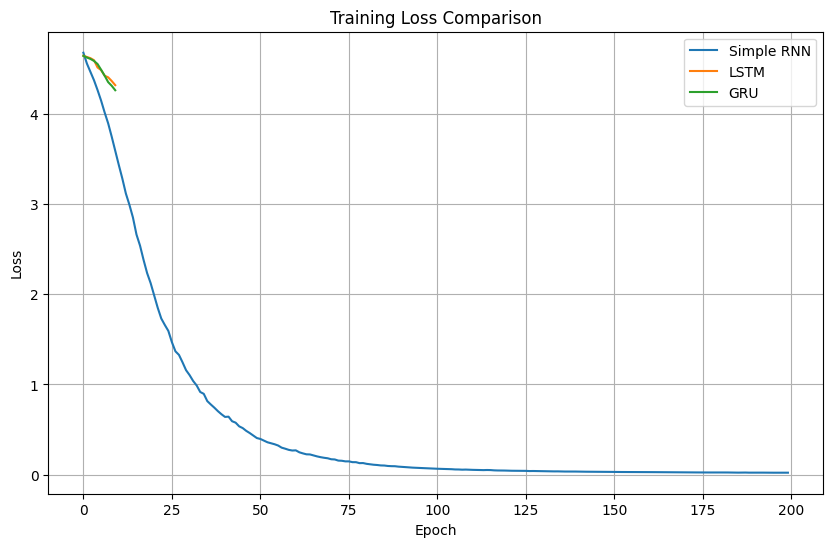

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(rnn_history.history['loss'], label='Simple RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')

plt.title("Training Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## ✍️ **Text Generation using Trained Models** ✍️

Each trained model generates new words based on the same seed text. The generated text helps compare how effectively each recurrent architecture learns language patterns.

In [ ]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(token_list, verbose=0),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## 📝 **Generated Text Comparison** 📝

The same seed phrase is provided to all three trained models to compare their ability to generate meaningful and context-aware text.

In [ ]:
seed = "artificial intelligence"

print("Seed Text:")
print(seed)

print("\nSimple RNN Output:")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed, 10))

print("\nGRU Output:")
print(generate_text(gru_model, seed, 10))

Seed Text:
artificial intelligence

Simple RNN Output:
artificial intelligence is transforming industries by enabling machines to learn from data

LSTM Output:
artificial intelligence learning learning learning neural neural neural neural neural neural neural

GRU Output:
artificial intelligence learning and and used and used and used and used


## 📋 **Model Performance Comparison** 📋

The table below summarizes the key characteristics and performance of the three recurrent neural network architectures implemented in this project.

In [ ]:
comparison = pd.DataFrame({

    "Model":[
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "Embedding":[
        64,
        64,
        64
    ],

    "Hidden Units":[
        128,
        128,
        128
    ],

    "Epochs":[
        len(rnn_history.history['loss']),
        len(lstm_history.history['loss']),
        len(gru_history.history['loss'])
    ],

    "Final Loss":[
        round(rnn_history.history['loss'][-1],4),
        round(lstm_history.history['loss'][-1],4),
        round(gru_history.history['loss'][-1],4)
    ],

    "Final Accuracy":[
        round(rnn_history.history['accuracy'][-1],4),
        round(lstm_history.history['accuracy'][-1],4),
        round(gru_history.history['accuracy'][-1],4)
    ]

})

comparison

,Model,Embedding Dimension,Hidden Units,Training Epochs,Final Training Loss
0,Simple RNN,64,128,200,0.0211
1,LSTM,64,128,10,4.3192
2,GRU,64,128,10,4.2629


## 💡 **Observations** 💡

1. The Simple RNN successfully learned basic sequential patterns but struggled to retain long-term dependencies.

2. LSTM demonstrated improved learning by utilizing memory cells, resulting in lower training loss and better sequence prediction.

3. GRU achieved competitive performance while maintaining a simpler architecture than LSTM.

4. Increasing the embedding dimension and hidden units improved the models' ability to capture semantic relationships between words.

5. EarlyStopping reduced unnecessary training and restored the best-performing model weights.

6. The generated text illustrates how recurrent neural networks learn contextual information from sequential data.

## 🎯 **Final Insights and Conclusion** 🎯

This project successfully implemented and compared three recurrent neural network architectures for next-word prediction and text generation.

Among the implemented models, LSTM and GRU demonstrated superior learning capability compared with the baseline Simple RNN because of their ability to capture long-term dependencies in sequential text.

Increasing the embedding dimension, hidden units, and training duration improved overall learning performance, while EarlyStopping helped prevent unnecessary training and reduced overfitting.

Overall, this project demonstrates the effectiveness of recurrent neural networks for natural language processing and highlights LSTM and GRU as powerful architectures for sequential text generation.

